In [36]:
import pandas as pd

In [37]:
df = pd.read_csv(
    "../../CSVs/time_series_30min_singleindex.csv",
    parse_dates=["utc_timestamp"]
)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]:,} columns.")

Loaded 100,802 rows and 41 columns.


Dataset shape: (100802, 41)
Duplicate rows: 0

Column audit:


,dtype,non_null,missing,missing_pct,unique
CY_load_forecast_entsoe_transparency,float64,42704,58098,57.64,29401
IE_sem_price_day_ahead,float64,64096,36706,36.41,8041
CY_load_actual_entsoe_transparency,float64,65836,34966,34.69,36487
GB_NIR_solar_capacity,float64,80593,20209,20.05,17
CY_wind_onshore_generation_actual,float64,86182,14620,14.50,10747
GB_GBN_solar_profile,float64,87497,13305,13.20,9006
GB_GBN_wind_offshore_profile,float64,87513,13289,13.18,7926
GB_GBN_wind_profile,float64,87513,13289,13.18,6752
GB_GBN_wind_onshore_profile,float64,87513,13289,13.18,6617
GB_NIR_wind_onshore_capacity,float64,87601,13201,13.10,31



Time coverage: 2014-12-31 23:00:00+00:00 to 2020-09-30 23:30:00+00:00
Most common time step: 0 days 00:30:00
Unexpected time steps: 0

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
GB_GBN_load_actual_entsoe_transparency,100786.0,34921.091005,7941.972811,248.00,28886.0000,35345.0000,40789.750000,71273.0000
IE_wind_onshore_generation_actual,100736.0,906.918619,699.096920,0.00,304.1675,750.9650,1408.072500,3330.9700
GB_GBN_wind_generation_actual,100712.0,4513.020038,2820.024709,0.00,2176.4500,4023.3550,6436.482500,14090.0500
GB_GBN_wind_offshore_generation_actual,100712.0,1901.708871,1422.827084,0.00,723.3175,1604.6800,2864.000000,6582.6100
GB_GBN_wind_onshore_generation_actual,100712.0,2611.311168,1640.892474,0.00,1225.0000,2322.0000,3734.835000,8353.0600
GB_UKM_wind_offshore_generation_actual,100712.0,1901.708871,1422.827084,0.00,723.3175,1604.6800,2864.000000,6582.6100
GB_GBN_solar_generation_actual,100684.0,1184.936166,1826.769449,0.00,0.0000,45.0000,1890.000000,9872.0000
GB_UKM_solar_generation_actual,100684.0,1184.936166,1826.769449,0.00,0.0000,45.0000,1890.000000,9872.0000
GB_NIR_wind_onshore_generation_actual,100628.0,235.056500,198.417591,0.25,70.1075,180.0100,364.810000,1014.6500
IE_sem_wind_onshore_generation_actual,100574.0,1142.020955,871.789237,0.55,392.2125,942.3950,1757.667500,4193.2100



Most complete numeric signals:


,dtype,non_null,missing,missing_pct,unique
GB_GBN_load_actual_entsoe_transparency,float64,100786,16,0.02,30839
IE_wind_onshore_generation_actual,float64,100736,66,0.07,79841
GB_GBN_wind_generation_actual,float64,100712,90,0.09,83670
GB_GBN_wind_offshore_generation_actual,float64,100712,90,0.09,76162
GB_GBN_wind_onshore_generation_actual,float64,100712,90,0.09,78669
GB_UKM_wind_offshore_generation_actual,float64,100712,90,0.09,76162
GB_GBN_solar_generation_actual,float64,100684,118,0.12,4993
GB_UKM_solar_generation_actual,float64,100684,118,0.12,4993
GB_NIR_wind_onshore_generation_actual,float64,100628,174,0.17,48585
IE_sem_wind_onshore_generation_actual,float64,100574,228,0.23,83311


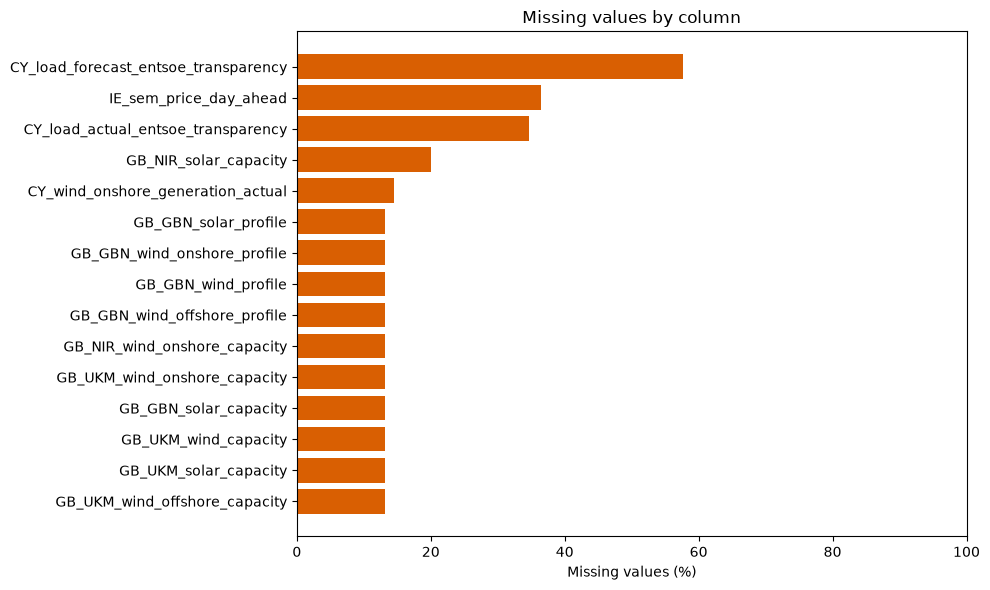

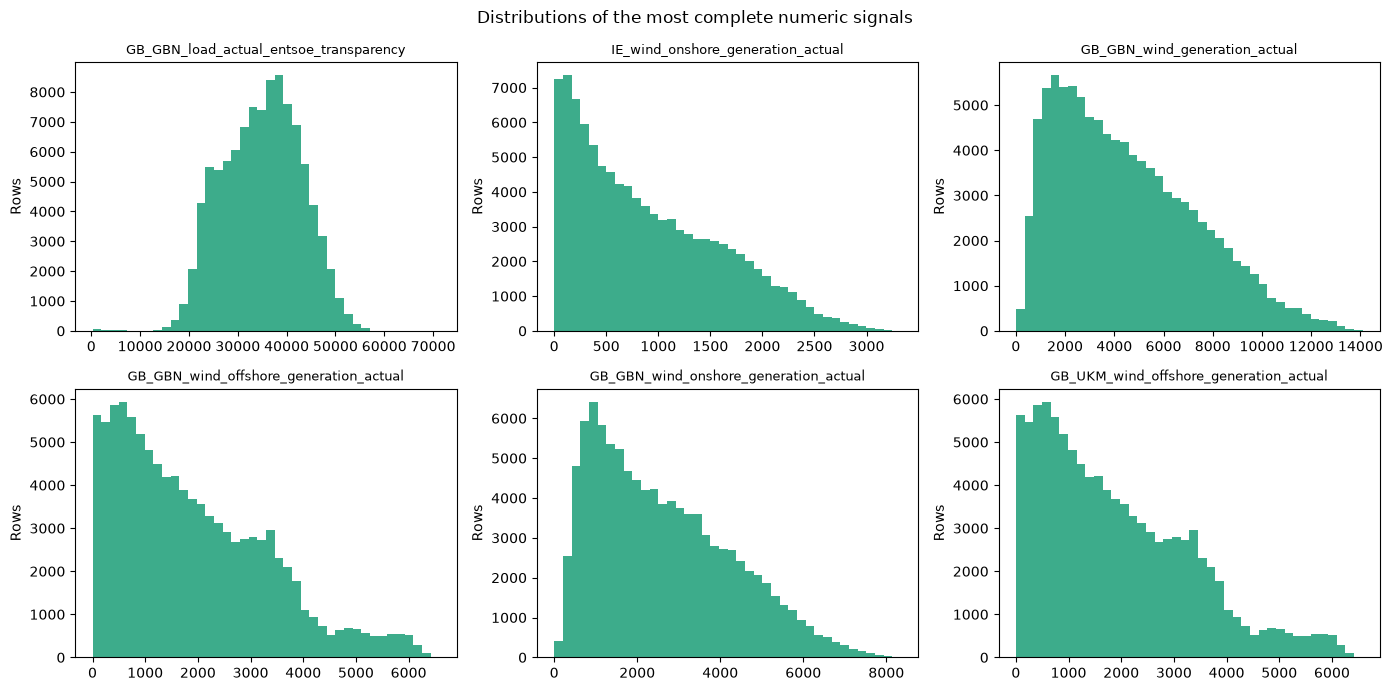

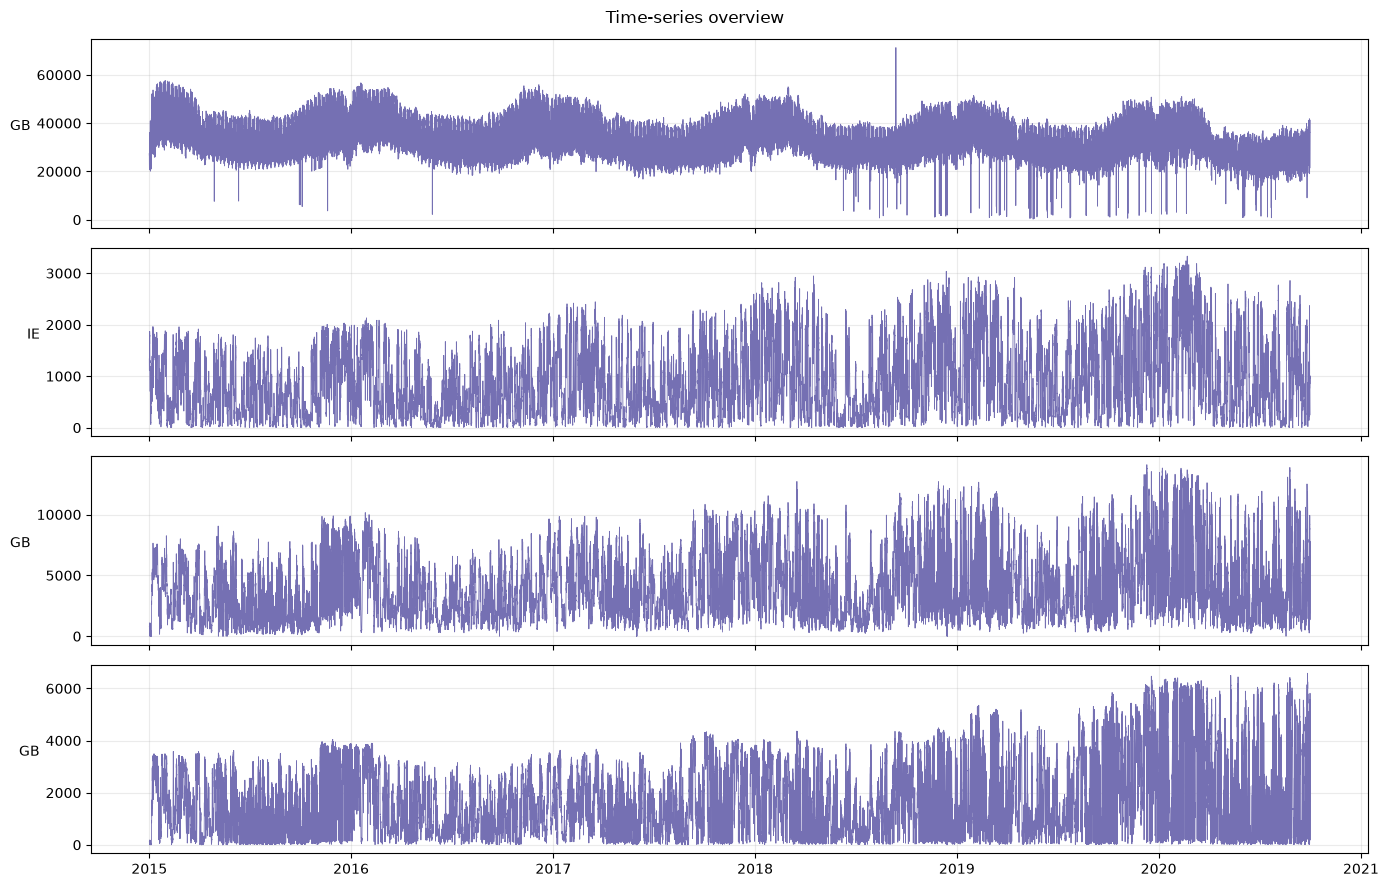

In [38]:
import matplotlib.pyplot as plt

# Keep the chronological order explicit for time-series checks and plots.
df = df.sort_values("utc_timestamp").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Duplicate rows:", f"{df.duplicated().sum():,}")

# Column-level data-quality audit.
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique": df.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

print("\nColumn audit:")
display(audit)

# Check whether observations arrive at the expected 30-minute frequency.
time_diff = df["utc_timestamp"].diff().dropna()
print("\nTime coverage:", df["utc_timestamp"].min(), "to", df["utc_timestamp"].max())
print("Most common time step:", time_diff.mode().iloc[0])
print("Unexpected time steps:", f"{(time_diff != pd.Timedelta(minutes=30)).sum():,}")

numeric_cols = df.select_dtypes(include="number").columns.tolist()
complete_numeric = audit.loc[numeric_cols].sort_values(
    ["missing_pct", "non_null"], ascending=[True, False]
)

print("\nNumeric summary:")
display(df[numeric_cols].describe().T.sort_values("count", ascending=False))

print("\nMost complete numeric signals:")
display(complete_numeric.head(10))

# Plot the 15 columns with the most missing values.
missing_plot = audit.head(15).sort_values("missing_pct")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing_plot.index, missing_plot["missing_pct"], color="#d95f02")
ax.set_title("Missing values by column")
ax.set_xlabel("Missing values (%)")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

# Plot distributions for the six most complete numeric series.
plot_cols = complete_numeric.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for axis, col in zip(axes.flat, plot_cols):
    axis.hist(df[col].dropna(), bins=40, color="#1b9e77", alpha=0.85)
    axis.set_title(col, fontsize=9)
    axis.set_ylabel("Rows")
for axis in axes.flat[len(plot_cols):]:
    axis.set_visible(False)
fig.suptitle("Distributions of the most complete numeric signals")
plt.tight_layout()
plt.show()

# Plot a readable time-series sample for the four most complete signals.
time_plot_cols = complete_numeric.head(4).index.tolist()
fig, axes = plt.subplots(len(time_plot_cols), 1, figsize=(14, 9), sharex=True)
if len(time_plot_cols) == 1:
    axes = [axes]
for axis, col in zip(axes, time_plot_cols):
    axis.plot(df["utc_timestamp"], df[col], linewidth=0.6, color="#7570b3")
    axis.set_ylabel(col.split("_")[0], rotation=0, ha="right")
    axis.grid(alpha=0.25)
fig.suptitle("Time-series overview")
plt.tight_layout()
plt.show()

Highest outlier rates among numeric columns:


,outlier_count,outlier_pct
CY_load_actual_entsoe_transparency,220,0.33
CY_load_forecast_entsoe_transparency,0,0.00
CY_wind_onshore_generation_actual,3172,3.68
GB_GBN_load_actual_entsoe_transparency,157,0.16
GB_GBN_load_forecast_entsoe_transparency,24,0.02
GB_GBN_solar_capacity,16753,19.12
GB_GBN_solar_generation_actual,7009,6.96
GB_GBN_solar_profile,5873,6.71
GB_GBN_wind_capacity,0,0.00
GB_GBN_wind_generation_actual,280,0.28


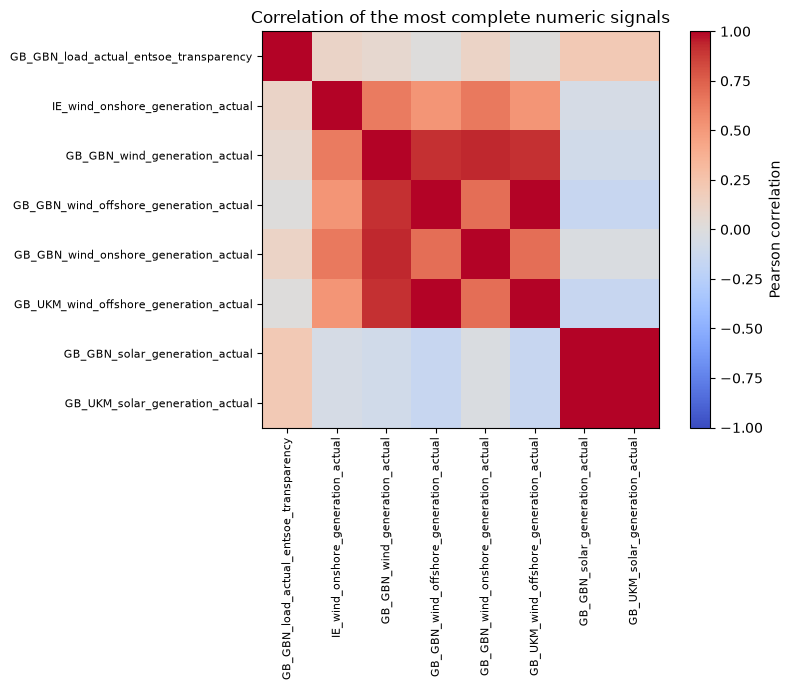

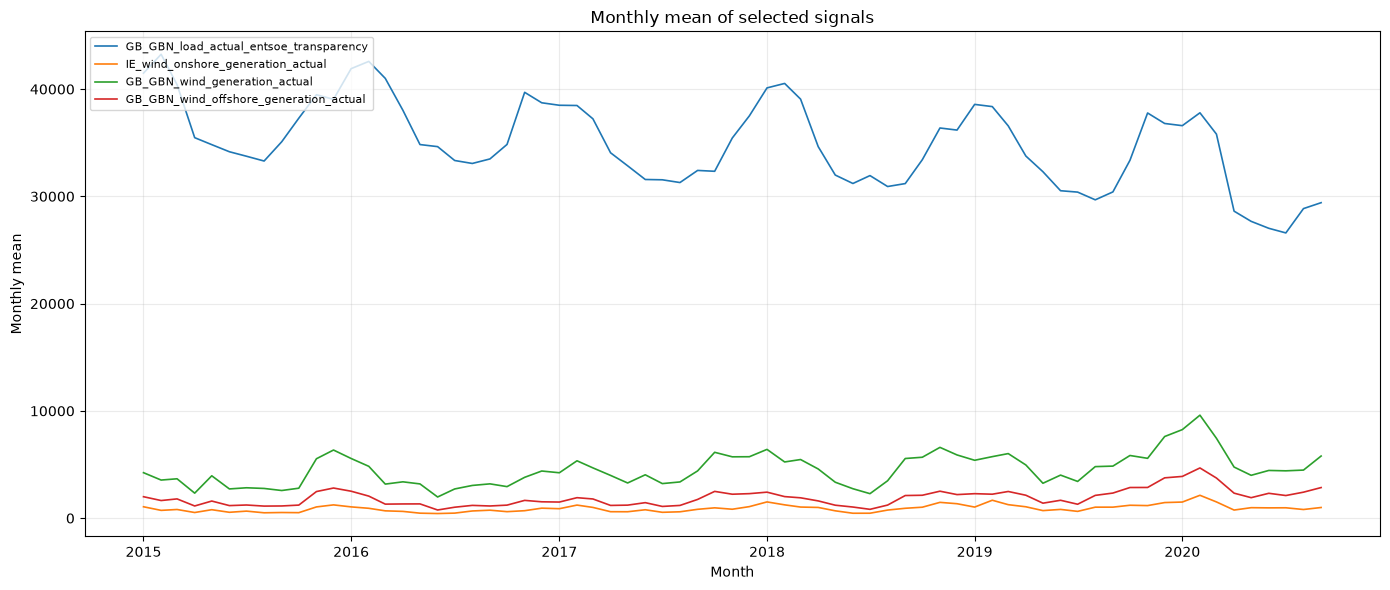

In [39]:
# Robust outlier screening using the 1.5 x IQR rule.
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
outlier_counts = ((df[numeric_cols] < (q1 - 1.5 * iqr)) | (df[numeric_cols] > (q3 + 1.5 * iqr))).sum()
outlier_rate = (outlier_counts / df[numeric_cols].notna().sum() * 100).sort_values(ascending=False)

print("Highest outlier rates among numeric columns:")
display(pd.DataFrame({"outlier_count": outlier_counts, "outlier_pct": outlier_rate.round(2)}).head(10))

# Correlations are most interpretable when restricted to the well-populated signals.
correlation_cols = complete_numeric.head(8).index.tolist()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(df[correlation_cols].corr(), vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(correlation_cols)), correlation_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(correlation_cols)), correlation_cols, fontsize=8)
ax.set_title("Correlation of the most complete numeric signals")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

# Monthly averages make long-term level and seasonality easier to see.
monthly = df.set_index("utc_timestamp")[complete_numeric.head(4).index].resample("MS").mean()
fig, ax = plt.subplots(figsize=(14, 6))
for col in monthly.columns:
    ax.plot(monthly.index, monthly[col], label=col, linewidth=1.2)
ax.set_title("Monthly mean of selected signals")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly mean")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [40]:
df.describe()

,CY_load_actual_entsoe_transparency,CY_load_forecast_entsoe_transparency,CY_wind_onshore_generation_actual,GB_GBN_load_actual_entsoe_transparency,GB_GBN_load_forecast_entsoe_transparency,GB_GBN_solar_capacity,GB_GBN_solar_generation_actual,GB_GBN_solar_profile,GB_GBN_wind_capacity,GB_GBN_wind_generation_actual,...,GB_UKM_wind_offshore_generation_actual,GB_UKM_wind_onshore_capacity,GB_UKM_wind_onshore_generation_actual,IE_load_actual_entsoe_transparency,IE_load_forecast_entsoe_transparency,IE_wind_onshore_generation_actual,IE_sem_load_actual_entsoe_transparency,IE_sem_load_forecast_entsoe_transparency,IE_sem_price_day_ahead,IE_sem_wind_onshore_generation_actual
count,65836.000000,42704.000000,86182.000000,100786.000000,100558.000000,87601.000000,100684.000000,87497.000000,87601.000000,100712.000000,...,100712.000000,87601.000000,100538.000000,99672.000000,99840.000000,100736.000000,99494.000000,98976.000000,64096.000000,100574.000000
mean,499.352000,550.395788,25.460517,34921.091005,33308.061537,7194.083584,1184.936166,0.158024,16251.558133,4513.020038,...,1901.708871,11008.182909,2846.784286,3191.228362,3282.446063,906.918619,4114.885913,4237.132535,47.343633,1142.020955
std,130.894224,154.212758,25.927694,7941.972811,7617.220738,1464.520616,1826.769449,0.241560,2973.705537,2820.024709,...,1422.827084,1794.559544,1786.630119,610.810710,672.755391,699.096920,834.710307,886.795281,21.124401,871.789237
min,186.570000,161.550000,0.000000,248.000000,455.000000,2664.000000,0.000000,0.000000,11554.000000,0.000000,...,0.000000,8173.000000,2.050000,1765.820000,1758.000000,0.000000,1993.630000,1992.000000,-100.000000,0.550000
25%,400.020000,437.530000,5.510000,28886.000000,27406.000000,7102.000000,0.000000,0.000000,13662.000000,2176.450000,...,723.317500,9245.000000,1342.240000,2684.237500,2725.000000,304.167500,3393.237500,3485.547500,34.957500,392.212500
50%,485.515000,525.605000,17.280000,35345.000000,33272.000000,8118.000000,45.000000,0.005500,15729.000000,4023.355000,...,1604.680000,11371.000000,2522.450000,3254.075000,3358.000000,750.965000,4192.590000,4318.230000,43.230000,942.395000
75%,586.772500,658.392500,37.500000,40789.750000,38944.000000,8188.000000,1890.000000,0.255500,19475.000000,6436.482500,...,2864.000000,12742.000000,4069.735000,3638.340000,3776.000000,1408.072500,4714.417500,4894.970000,54.440000,1757.667500
max,975.770000,940.150000,151.950000,71273.000000,56316.000000,8256.000000,9872.000000,1.372000,20612.000000,14090.050000,...,6582.610000,13297.000000,9080.960000,5024.260000,5325.000000,3330.970000,6514.810000,6762.490000,1000.000000,4193.210000


In [41]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100802 entries, 0 to 100801
Data columns (total 41 columns):
 #   Column                                    Non-Null Count   Dtype              
---  ------                                    --------------   -----              
 0   utc_timestamp                             100802 non-null  datetime64[us, UTC]
 1   cet_cest_timestamp                        100802 non-null  str                
 2   CY_load_actual_entsoe_transparency        65836 non-null   float64            
 3   CY_load_forecast_entsoe_transparency      42704 non-null   float64            
 4   CY_wind_onshore_generation_actual         86182 non-null   float64            
 5   GB_GBN_load_actual_entsoe_transparency    100786 non-null  float64            
 6   GB_GBN_load_forecast_entsoe_transparency  100558 non-null  float64            
 7   GB_GBN_solar_capacity                     87601 non-null   float64            
 8   GB_GBN_solar_generation_actual            100684 non-nu

None

In [42]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
100797    False
100798    False
100799    False
100800    False
100801    False
Length: 100802, dtype: bool

In [43]:
df


,utc_timestamp,cet_cest_timestamp,CY_load_actual_entsoe_transparency,CY_load_forecast_entsoe_transparency,CY_wind_onshore_generation_actual,GB_GBN_load_actual_entsoe_transparency,GB_GBN_load_forecast_entsoe_transparency,GB_GBN_solar_capacity,GB_GBN_solar_generation_actual,GB_GBN_solar_profile,...,GB_UKM_wind_offshore_generation_actual,GB_UKM_wind_onshore_capacity,GB_UKM_wind_onshore_generation_actual,IE_load_actual_entsoe_transparency,IE_load_forecast_entsoe_transparency,IE_wind_onshore_generation_actual,IE_sem_load_actual_entsoe_transparency,IE_sem_load_forecast_entsoe_transparency,IE_sem_price_day_ahead,IE_sem_wind_onshore_generation_actual
0,2014-12-31 23:00:00+00:00,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-31 23:30:00+00:00,2015-01-01T00:30:00+0100,NaN,NaN,NaN,NaN,NaN,2664.0,NaN,NaN,...,NaN,8173.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01 00:00:00+00:00,2015-01-01T01:00:00+0100,NaN,NaN,NaN,NaN,NaN,2669.0,NaN,NaN,...,NaN,8174.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-01 00:30:00+00:00,2015-01-01T01:30:00+0100,NaN,NaN,NaN,26758.0,32057.0,2669.0,NaN,NaN,...,NaN,8174.0,385.33,2832.37,3550.0,1335.88,3681.37,NaN,NaN,1721.21
4,2015-01-01 01:00:00+00:00,2015-01-01T02:00:00+0100,NaN,NaN,NaN,27561.0,32135.0,2669.0,NaN,NaN,...,NaN,8174.0,1050.04,2726.20,3403.0,1289.69,3523.20,NaN,NaN,1675.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100797,2020-09-30 21:30:00+00:00,2020-09-30T23:30:00+0200,421.965,NaN,24.67,28837.0,25534.0,NaN,NaN,NaN,...,5632.06,NaN,2097.58,3285.30,3256.0,394.57,4139.30,4463.28,NaN,463.72
100798,2020-09-30 22:00:00+00:00,2020-10-01T00:00:00+0200,405.490,NaN,18.19,25474.0,23904.0,NaN,NaN,NaN,...,5814.75,NaN,2023.58,3095.52,3125.0,343.07,3884.52,4256.67,NaN,401.47
100799,2020-09-30 22:30:00+00:00,2020-10-01T00:30:00+0200,395.660,NaN,18.80,23735.0,22858.0,NaN,NaN,NaN,...,180.56,NaN,1234.44,2949.32,2949.0,308.40,3676.32,3995.56,NaN,365.37
100800,2020-09-30 23:00:00+00:00,2020-10-01T01:00:00+0200,386.990,NaN,23.48,21528.0,22140.0,NaN,NaN,NaN,...,5571.92,NaN,1809.62,2854.39,2784.0,250.31,3534.39,3756.39,NaN,300.06


In [45]:
df1 = pd.read_csv(
    "../../CSVs/Bangladesh_Carbon_Intensity.csv"
)

print(f"Loaded {df1.shape[0]:,} rows and {df1.shape[1]:,} columns.")

Loaded 288 rows and 5 columns.


In [54]:
df1

,datetime,updatedAt,isEstimated,estimationMethod,carbon_intensity_gCO2eq_kWh
0,2026-08-15T22:20:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
1,2026-08-15T22:25:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
2,2026-08-15T22:30:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
3,2026-08-15T22:35:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
4,2026-08-15T22:40:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
...,...,...,...,...,...
283,2026-08-16T21:55:00.000Z,2026-08-16T15:20:54.503Z,True,TIME_SLICER_AVERAGE,626
284,2026-08-16T22:00:00.000Z,2026-08-16T16:20:30.468Z,True,TIME_SLICER_AVERAGE,625
285,2026-08-16T22:05:00.000Z,2026-08-16T16:20:30.468Z,True,TIME_SLICER_AVERAGE,625
286,2026-08-16T22:10:00.000Z,2026-08-16T16:20:30.468Z,True,TIME_SLICER_AVERAGE,625


In [49]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   datetime                     288 non-null    str  
 1   updatedAt                    288 non-null    str  
 2   isEstimated                  288 non-null    bool 
 3   estimationMethod             288 non-null    str  
 4   carbon_intensity_gCO2eq_kWh  288 non-null    int64
dtypes: bool(1), int64(1), str(3)
memory usage: 28.3 KB


In [50]:
df1.describe()

,carbon_intensity_gCO2eq_kWh
count,288.000000
mean,626.833333
std,12.470453
min,602.000000
25%,619.750000
50%,626.000000
75%,636.000000
max,646.000000


In [53]:
display((("Shape:", df1.shape)))
print("\nColumns:")
display(df1.columns.tolist())

print("\nFirst 5 rows:")
display(df1.head())

print("\nMissing values:")
display(df1.isna().mean().sort_values(ascending=False))

print("\nData types:")
display(df1.dtypes)

print("\nDate range:")
for col in df1.columns:
    if "date" in col.lower() or "time" in col.lower():
        display((col, df1[col].min(), "->", df1[col].max()))

('Shape:', (288, 5))


Columns:


['datetime',
 'updatedAt',
 'isEstimated',
 'estimationMethod',
 'carbon_intensity_gCO2eq_kWh']


First 5 rows:


,datetime,updatedAt,isEstimated,estimationMethod,carbon_intensity_gCO2eq_kWh
0,2026-08-15T22:20:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
1,2026-08-15T22:25:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
2,2026-08-15T22:30:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
3,2026-08-15T22:35:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625
4,2026-08-15T22:40:00.000Z,2026-08-15T16:20:32.445Z,True,TIME_SLICER_AVERAGE,625


...


Data types:


datetime                         str
updatedAt                        str
isEstimated                     bool
estimationMethod                 str
carbon_intensity_gCO2eq_kWh    int64
dtype: object


Date range:


('datetime', '2026-08-15T22:20:00.000Z', '->', '2026-08-16T22:15:00.000Z')

('updatedAt', '2026-08-15T16:20:32.445Z', '->', '2026-08-16T16:20:30.468Z')

## EDA Findings

- The dataset contains 100,802 rows and 41 columns, representing a 30-minute resolution time series.
- The time coverage extends from December 31, 2014 to September 30, 2020, with a consistent 30-minute time step.
- Duplicate-row checking shows 0 duplicate records, indicating that the time-series rows are unique.
- The dataset contains electricity load, load forecasts, solar generation, wind generation, renewable-energy capacity, and profile-related variables.
- Missing values are present across several variables. The most complete signals have only a small percentage of missing observations, while some variables such as CY load forecast contain considerably more missing data.
- Outlier analysis shows that some renewable-generation and capacity variables contain observations identified as outliers using the 1.5 × IQR rule.
- The dataset is suitable for temporal trend analysis, renewable-energy analysis, forecasting, and feature engineering, but missing values and outliers should be considered before predictive modeling.